# KDD Phase 2A — Feature Engineering & EDA
## Predicting When Stronger Models Win from Prompt Features

This notebook implements Phase 2A:
1. **Load & validate** the Phase 1 output (`arena_enriched_phase1.parquet`)
2. **Tier 2 feature engineering** — readability, constraints, entropy, prompt length
3. **Tier 3 feature engineering** — sentence-transformer embeddings (PCA-reduced), response divergence
4. **Exploratory Data Analysis** — feature distributions, correlations, model-pair analysis, language stratification
5. **Save** enriched dataset and artifacts for Phase 2B

**Input:** `arena_enriched_phase1.parquet` (79,437 rows × 48 columns)
**Output:** `arena_enriched_phase2.parquet`, `phase2_artifacts.pkl`

---
## 0. Setup

In [1]:
# Uncomment to install dependencies if needed
# !pip install -q sentence-transformers textstat

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Setup complete.")

Setup complete.


---
## Step 2A-0: Data Loading & Validation

In [2]:
df = pd.read_parquet('arena_enriched_phase1.parquet')
print(f"Loaded: {df.shape}")

Loaded: (79437, 48)


In [3]:
# --- Row count ---
assert len(df) == 79437, f"Expected 79,437 rows, got {len(df)}"

# --- Required columns from Phase 1 ---
required_cols = [
    'prompt_text', 'strong_model_won', 'domain_bucket', 'language',
    'elo_domain_gap', 'stronger_model_name', 'weaker_model_name',
    'prompt_word_count', 'is_code', 'cat_if_score',
    'cat_math', 'cat_coding', 'cat_creative_writing', 'cat_instruction_following',
    'cat_complexity', 'cat_creativity', 'cat_domain_knowledge',
    'cat_problem_solving', 'cat_real_world', 'cat_specificity', 'cat_technical_accuracy',
    'meta_user_tokens', 'meta_turns',
    'meta_assistant_a_tokens', 'meta_assistant_b_tokens',
    'meta_headers_a', 'meta_headers_b',
    'meta_lists_ordered_a', 'meta_lists_unordered_a',
    'meta_lists_ordered_b', 'meta_lists_unordered_b',
    'meta_bold_a', 'meta_bold_b',
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

# --- Class balance ---
pos_rate = df['strong_model_won'].mean()
print(f"Class balance: {pos_rate:.3f} positive (strong won) / {1 - pos_rate:.3f} negative")
assert 0.54 < pos_rate < 0.58, f"Unexpected class balance: {pos_rate:.3f}"

# --- Domain bucket distribution ---
print(f"\nDomain buckets:\n{df['domain_bucket'].value_counts().to_string()}")

# --- Null check on critical columns ---
null_counts = df[required_cols].isnull().sum()
has_nulls = null_counts[null_counts > 0]
if len(has_nulls) > 0:
    print(f"\nWarning — columns with nulls:\n{has_nulls.to_string()}")
else:
    print("\nNo nulls in required columns.")

print("\nValidation passed.")

Class balance: 0.560 positive (strong won) / 0.440 negative

Domain buckets:
domain_bucket
chat                47537
code                21180
creative_writing     6051
math_science         4669

Warning — columns with nulls:
cat_if_score    2

Validation passed.


---
## Step 2A-1: Tier 2 Feature Engineering (Lightweight, No GPU)

### 2A-1a: Readability Metrics

In [4]:
import textstat

df['flesch_kincaid_grade'] = df['prompt_text'].apply(textstat.flesch_kincaid_grade)
df['coleman_liau_index'] = df['prompt_text'].apply(textstat.coleman_liau_index)
df['automated_readability'] = df['prompt_text'].apply(textstat.automated_readability_index)
df['reading_ease'] = df['prompt_text'].apply(textstat.flesch_reading_ease)

# Clip degenerate scores for very short prompts (<=3 words) to domain-bucket median
short_mask = df['prompt_word_count'] <= 3
print(f"Short prompts (<=3 words): {short_mask.sum()}")

for col in ['flesch_kincaid_grade', 'coleman_liau_index', 'automated_readability', 'reading_ease']:
    df.loc[short_mask, col] = df.loc[short_mask, 'domain_bucket'].map(
        df.loc[~short_mask].groupby('domain_bucket')[col].median()
    )

print("Readability features computed.")
df[['flesch_kincaid_grade', 'coleman_liau_index', 'automated_readability', 'reading_ease']].describe()

[nltk_data] Zip Slip blocked: cmudict/


Short prompts (<=3 words): 11052
Readability features computed.


,flesch_kincaid_grade,coleman_liau_index,automated_readability,reading_ease
count,79437.000000,79437.000000,79437.000000,79437.000000
mean,7.518005,11.844545,11.210208,65.592053
std,23.768307,78.906339,78.922207,122.491701
min,-3.400000,-39.600000,-16.220000,-27144.175000
25%,3.755000,6.015385,4.996923,52.265000
50%,6.458571,9.266667,8.190000,69.785000
75%,9.617763,13.114286,12.339375,85.139474
max,4540.103038,18015.120000,18284.130000,121.220000


### 2A-1b: Constraint & Structure Counting

In [5]:
def count_constraints(text):
    """Count explicit instructional constraints in a prompt."""
    if not text or not isinstance(text, str):
        return {}

    text_lower = text.lower()

    return {
        'n_questions': text.count('?'),
        'n_code_fences': text.count('```'),
        'n_urls': len(re.findall(r'https?://\S+', text)),
        'has_numbered_list': int(bool(re.search(r'^\s*\d+[\.\)]\s', text, re.MULTILINE))),
        'n_negation_constraints': len(re.findall(
            r'\b(do not|don\'t|must not|never|avoid|without|no +\w+ing)\b', text_lower
        )),
        'n_positive_constraints': len(re.findall(
            r'\b(must include|make sure|ensure|always|exactly \d+|in \d+ words|format as|write in)\b', text_lower
        )),
        'n_sub_tasks': len(re.findall(r'^\s*[-•*]\s', text, re.MULTILINE)),
        'has_persona_instruction': int(bool(re.findall(
            r'\b(act as|you are|pretend|role[- ]?play|imagine you)\b', text_lower
        ))),
        'has_output_format': int(bool(re.findall(
            r'\b(json|csv|table|bullet|markdown|xml|yaml|list format)\b', text_lower
        ))),
    }

constraint_df = df['prompt_text'].apply(count_constraints).apply(pd.Series)
df = pd.concat([df, constraint_df], axis=1)

# Derived: total constraint count
df['total_constraints'] = (
    df['n_negation_constraints'] + df['n_positive_constraints'] +
    df['has_numbered_list'] + df['n_sub_tasks'] + df['has_output_format']
)

print("Constraint features computed.")
print(df[['total_constraints', 'n_questions', 'n_code_fences', 'has_persona_instruction']].describe())

Constraint features computed.
       total_constraints  n_questions  n_code_fences  has_persona_instruction
count       79437.000000  79437.00000   79437.000000             79437.000000
mean            0.347873      0.45042       0.022911                 0.015761
std             4.158367      1.38549       0.387605                 0.124550
min             0.000000      0.00000       0.000000                 0.000000
25%             0.000000      0.00000       0.000000                 0.000000
50%             0.000000      0.00000       0.000000                 0.000000
75%             0.000000      1.00000       0.000000                 0.000000
max           329.000000    133.00000      36.000000                 1.000000


### 2A-1c: Prompt Entropy

In [6]:
def char_entropy(text):
    """Character-level Shannon entropy."""
    if not text or len(text) < 2:
        return 0.0
    counts = Counter(text.lower())
    n = len(text)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())

def word_entropy(text):
    """Word-level Shannon entropy."""
    words = text.lower().split() if text else []
    if len(words) < 2:
        return 0.0
    counts = Counter(words)
    n = len(words)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())

df['char_entropy'] = df['prompt_text'].apply(char_entropy)
df['word_entropy'] = df['prompt_text'].apply(word_entropy)

print("Entropy features computed.")
df[['char_entropy', 'word_entropy']].describe()

Entropy features computed.


,char_entropy,word_entropy
count,79437.000000,79437.000000
mean,4.076377,3.523198
std,0.618086,1.723922
min,-0.000000,0.000000
25%,3.837593,2.584963
50%,4.084352,3.546594
75%,4.316709,4.615312
max,8.082696,11.571888


### 2A-1d: Relative Prompt Length

In [7]:
domain_median_length = df.groupby('domain_bucket')['prompt_word_count'].transform('median')
df['relative_prompt_length'] = df['prompt_word_count'] / domain_median_length.clip(lower=1)
df['log_prompt_length'] = np.log1p(df['prompt_word_count'])

print("Prompt length features computed.")
df[['relative_prompt_length', 'log_prompt_length']].describe()

Prompt length features computed.


,relative_prompt_length,log_prompt_length
count,79437.000000,79437.000000
mean,3.237704,2.727122
std,11.761150,1.236822
min,0.058824,0.693147
25%,0.454545,1.945910
50%,1.000000,2.564949
75%,2.272727,3.401197
max,685.352941,9.363233


### 2A-1e: Handle `cat_if_score` NaN

In [8]:
assert 'cat_if_score' in df.columns
n_na = df['cat_if_score'].isna().sum()
if n_na > 0:
    df['cat_if_score'] = df['cat_if_score'].fillna(df['cat_if_score'].median())
    print(f"Imputed {n_na} NaN values in cat_if_score")
else:
    print("No NaN values in cat_if_score")

Imputed 2 NaN values in cat_if_score


### 2A-1f: Language & Multi-Script Detection

In [9]:
def detect_non_ascii_ratio(text):
    """Fraction of characters that are non-ASCII."""
    if not text:
        return 0.0
    non_ascii = sum(1 for c in text if ord(c) > 127)
    return non_ascii / len(text)

df['non_ascii_ratio'] = df['prompt_text'].apply(detect_non_ascii_ratio)
df['is_english'] = (df['language'] == 'en').astype(int)

print("Language features computed.")
print(f"English prompts: {df['is_english'].mean():.1%}")
print(f"Mean non-ASCII ratio: {df['non_ascii_ratio'].mean():.4f}")

Language features computed.
English prompts: 52.3%
Mean non-ASCII ratio: 0.1815


### Checkpoint 2A-1: Verify Tier 2 Features

In [10]:
tier2_features = [
    'flesch_kincaid_grade', 'coleman_liau_index', 'automated_readability', 'reading_ease',
    'n_questions', 'n_code_fences', 'n_urls', 'has_numbered_list',
    'n_negation_constraints', 'n_positive_constraints', 'n_sub_tasks',
    'has_persona_instruction', 'has_output_format', 'total_constraints',
    'char_entropy', 'word_entropy',
    'relative_prompt_length', 'log_prompt_length',
    'non_ascii_ratio', 'is_english',
]

for f in tier2_features:
    assert f in df.columns, f"Missing feature: {f}"
    assert df[f].isna().sum() == 0, f"NaN values in: {f}"

print(f"All {len(tier2_features)} Tier 2 features present and NaN-free.")

# Correlations with target
print("\n--- Tier 2 feature correlations with strong_model_won ---")
corrs = df[tier2_features + ['strong_model_won']].corr()['strong_model_won'].drop('strong_model_won')
print(corrs.sort_values(ascending=False).to_string())

All 20 Tier 2 features present and NaN-free.

--- Tier 2 feature correlations with strong_model_won ---
non_ascii_ratio            0.035162
char_entropy               0.028155
reading_ease               0.005848
coleman_liau_index        -0.000250
automated_readability     -0.000785
n_urls                    -0.001089
n_questions               -0.005410
flesch_kincaid_grade      -0.005537
n_sub_tasks               -0.006698
n_negation_constraints    -0.007666
n_code_fences             -0.007860
total_constraints         -0.008697
n_positive_constraints    -0.010514
has_persona_instruction   -0.011011
has_numbered_list         -0.011153
relative_prompt_length    -0.012719
word_entropy              -0.012787
has_output_format         -0.013477
log_prompt_length         -0.013672
is_english                -0.027962


---
## Step 2A-2: Tier 3 Feature Engineering (GPU Required)

### 2A-2a: Sentence Transformer Embeddings

In [11]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load sentence-transformer model
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

# Encode all prompts
embeddings = embedder.encode(
    df['prompt_text'].fillna('').tolist(),
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f"Embeddings shape: {embeddings.shape}")

Using device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8400.68it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/311 [00:00<?, ?it/s]

...

Batches:  96%|█████████▌| 298/311 [00:44<00:00, 29.30it/s]

Batches:  97%|█████████▋| 302/311 [00:45<00:00, 31.60it/s]

Batches:  98%|█████████▊| 306/311 [00:45<00:00, 32.33it/s]

Batches: 100%|██████████| 311/311 [00:45<00:00,  6.87it/s]

Embeddings shape: (79437, 384)


In [12]:
# Reproduce the SAME train/val/test split from Phase 1
train_idx, temp_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42,
    stratify=df['strong_model_won']
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42,
    stratify=df.iloc[temp_idx]['strong_model_won']
)

# Verify split sizes match Phase 1
assert len(train_idx) == 63549, f"Train size mismatch: {len(train_idx)} != 63549"
assert len(val_idx) == 7944, f"Val size mismatch: {len(val_idx)} != 7944"
assert len(test_idx) == 7944, f"Test size mismatch: {len(test_idx)} != 7944"
print(f"Split sizes — Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print(f"Train positive rate: {df.iloc[train_idx]['strong_model_won'].mean():.3f}")
print(f"Test positive rate:  {df.iloc[test_idx]['strong_model_won'].mean():.3f}")

# Fit PCA on train set only (prevent data leakage)
pca = PCA(n_components=48, random_state=42)
pca.fit(embeddings[train_idx])

embeddings_reduced = pca.transform(embeddings)
print(f"Explained variance (48 components): {pca.explained_variance_ratio_.sum():.3f}")

# Add as columns
for i in range(48):
    df[f'emb_{i:02d}'] = embeddings_reduced[:, i]

Split sizes — Train: 63549, Val: 7944, Test: 7944
Train positive rate: 0.560
Test positive rate:  0.560


Explained variance (48 components): 0.477


### 2A-2b: Response Divergence Features

**Caveat:** These use information from *both models' responses* — not usable at inference time for a real-time router. Included for analysis/insight only.

In [13]:
# Token count divergence
df['response_length_ratio'] = (
    df['meta_assistant_a_tokens'] / df['meta_assistant_b_tokens'].clip(lower=1)
)
df['response_length_diff'] = (
    df['meta_assistant_a_tokens'] - df['meta_assistant_b_tokens']
).abs()

# Formatting divergence
df['header_diff'] = (df['meta_headers_a'] - df['meta_headers_b']).abs()
df['list_diff'] = (
    (df['meta_lists_ordered_a'] + df['meta_lists_unordered_a']) -
    (df['meta_lists_ordered_b'] + df['meta_lists_unordered_b'])
).abs()
df['bold_diff'] = (df['meta_bold_a'] - df['meta_bold_b']).abs()

# Total formatting divergence (composite)
df['formatting_divergence'] = df['header_diff'] + df['list_diff'] + df['bold_diff']

print("Response divergence features computed.")
df[['response_length_ratio', 'response_length_diff', 'formatting_divergence']].describe()

Response divergence features computed.


,response_length_ratio,response_length_diff,formatting_divergence
count,79437.000000,79437.000000,79437.000000
mean,2.310370,732.207485,36.036948
std,33.993734,1330.533245,55.713802
min,0.000000,0.000000,0.000000
25%,0.551985,135.000000,9.000000
50%,1.000000,404.000000,23.000000
75%,1.832370,897.000000,46.000000
max,6987.000000,65565.000000,3424.000000


### Checkpoint 2A-2: Verify Tier 3 Features

In [14]:
tier3_features = [f'emb_{i:02d}' for i in range(48)] + [
    'response_length_ratio', 'response_length_diff',
    'header_diff', 'list_diff', 'bold_diff', 'formatting_divergence',
]

for f in tier3_features:
    assert f in df.columns, f"Missing: {f}"
    assert df[f].isna().sum() == 0, f"NaN in: {f}"

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Total new features: {len(tier2_features) + len(tier3_features)}")
print(f"DataFrame shape: {df.shape}")

PCA explained variance: 0.477
Total new features: 74
DataFrame shape: (79437, 122)


---
## Step 2A-3: Save Enriched Dataset

In [15]:
import pickle

# Save enriched parquet
df.to_parquet('arena_enriched_phase2.parquet', index=False)
print(f"Saved: arena_enriched_phase2.parquet ({df.shape})")

# Save artifacts for Phase 2B reproducibility
with open('phase2_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'pca': pca,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'test_idx': test_idx,
        'tier2_features': tier2_features,
        'tier3_features': tier3_features,
    }, f)
print("Saved: phase2_artifacts.pkl")

Saved: arena_enriched_phase2.parquet ((79437, 122))
Saved: phase2_artifacts.pkl


---
## Step 2A-4: Exploratory Data Analysis

### 2A-4a: Feature Distribution Overview

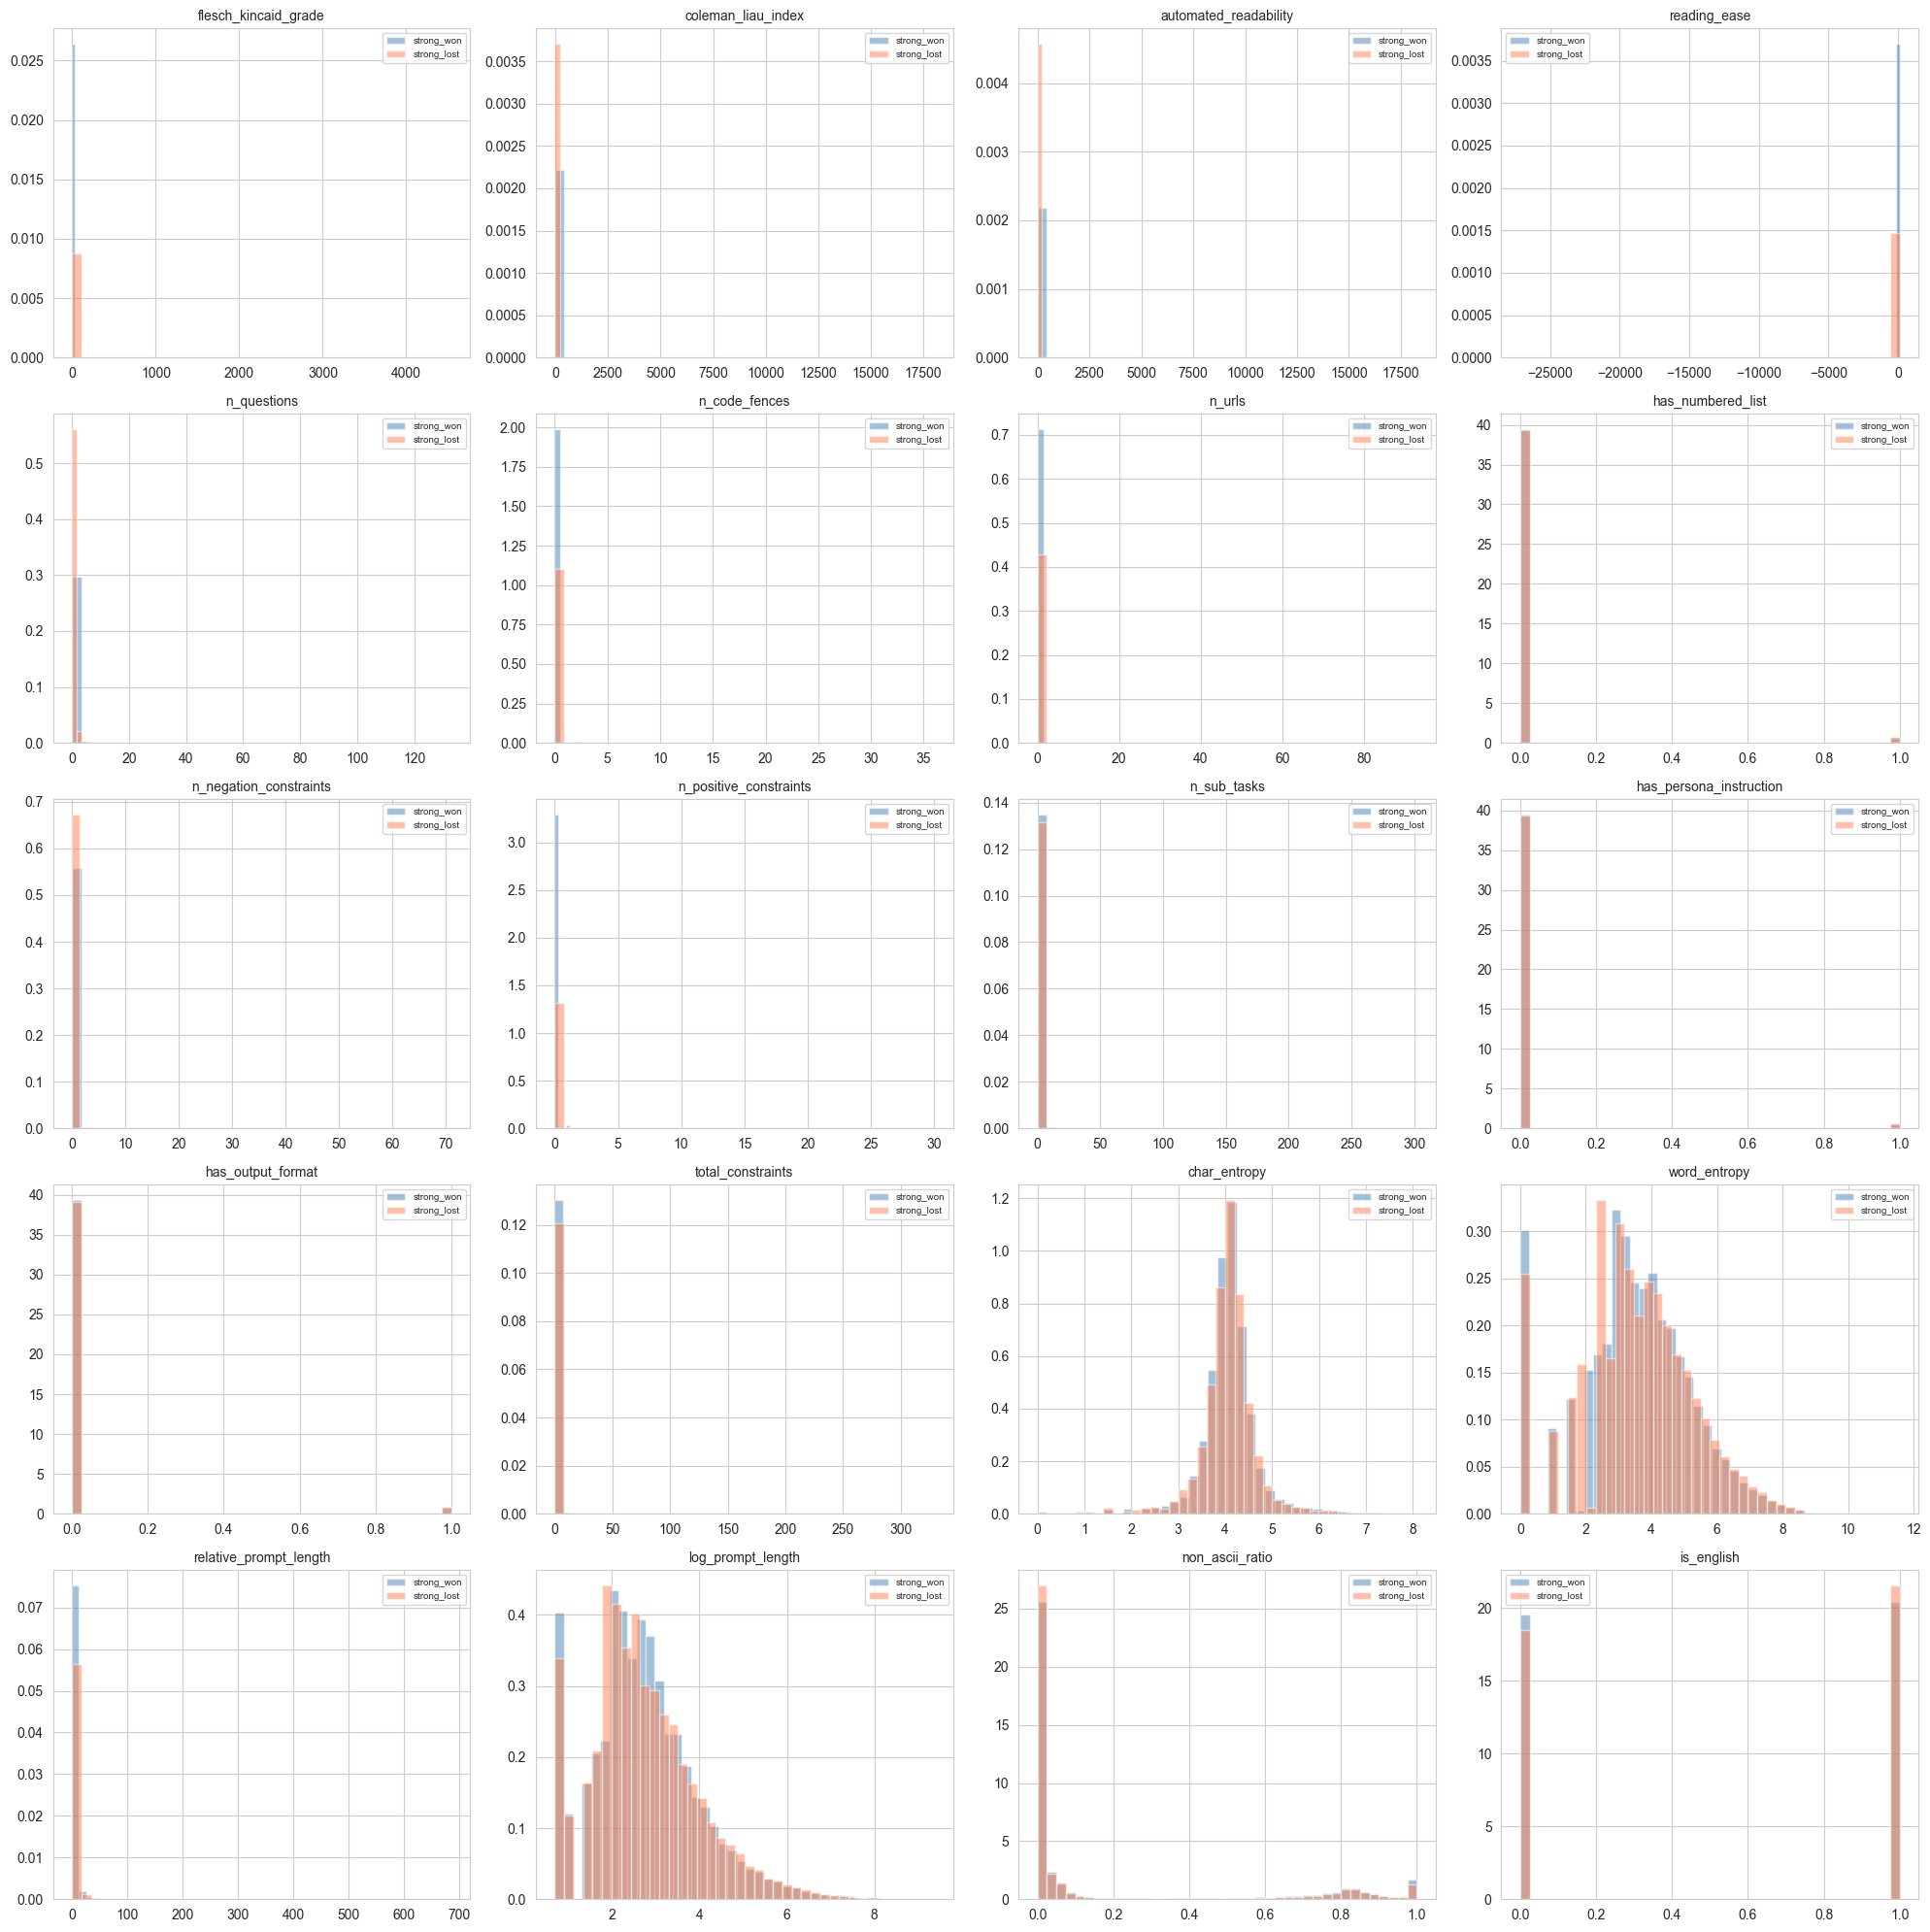

In [16]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
for ax, feat in zip(axes.ravel(), tier2_features):
    for label, color in [(1, 'steelblue'), (0, 'coral')]:
        subset = df[df['strong_model_won'] == label][feat]
        ax.hist(subset, bins=40, alpha=0.5, color=color,
                label='strong_won' if label else 'strong_lost', density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('tier2_feature_distributions.png', dpi=150)
plt.show()

### 2A-4b: Feature Correlation Heatmap

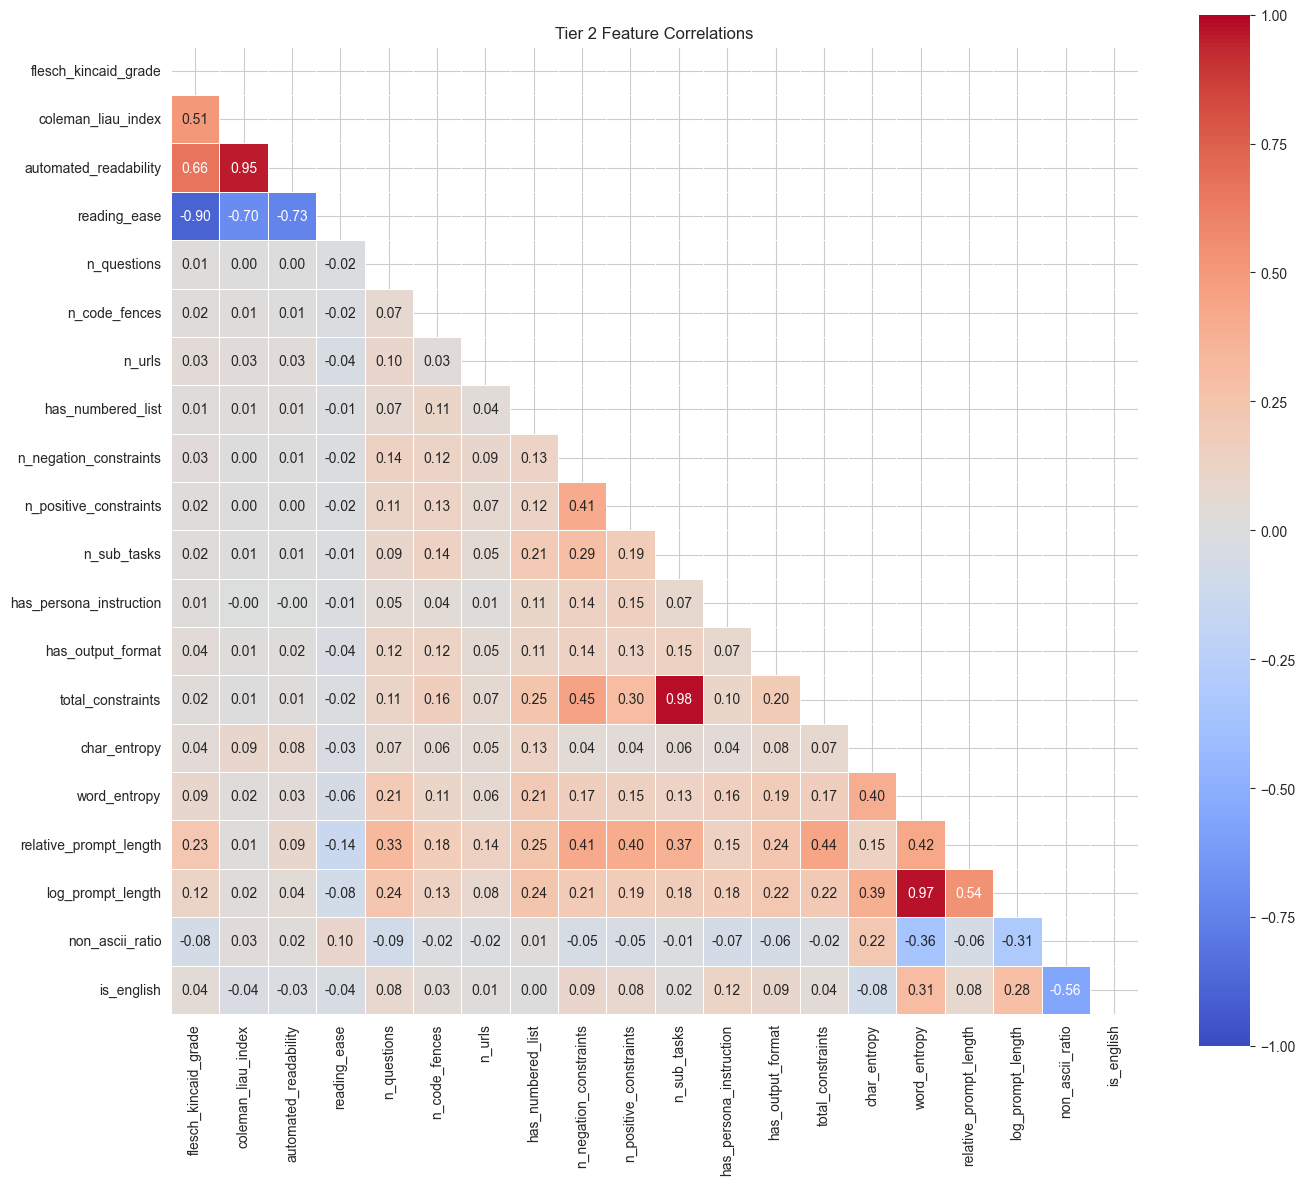

Highly correlated feature pairs (|r| > 0.9):
  coleman_liau_index <-> automated_readability: r=0.953
  n_sub_tasks <-> total_constraints: r=0.983
  word_entropy <-> log_prompt_length: r=0.975


In [17]:
corr_matrix = df[tier2_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Tier 2 Feature Correlations')
plt.tight_layout()
plt.savefig('tier2_feature_correlations.png', dpi=150)
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(tier2_features)):
    for j in range(i + 1, len(tier2_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr.append((tier2_features[i], tier2_features[j], r))
if high_corr:
    print("Highly correlated feature pairs (|r| > 0.9):")
    for f1, f2, r in high_corr:
        print(f"  {f1} <-> {f2}: r={r:.3f}")
else:
    print("No feature pairs with |r| > 0.9.")

### 2A-4c: Model-Pair Analysis

In [18]:
pair_stats = df.groupby(['stronger_model_name', 'weaker_model_name']).agg(
    n_battles=('strong_model_won', 'count'),
    win_rate=('strong_model_won', 'mean'),
).reset_index()

pair_stats_filtered = pair_stats[pair_stats['n_battles'] >= 30].copy()
pair_stats_filtered = pair_stats_filtered.sort_values('win_rate', ascending=False)

print(f"Model pairs with >=30 battles: {len(pair_stats_filtered)}")
print(f"\n--- Most predictable pairs (strong model dominates) ---")
print(pair_stats_filtered.head(15).to_string(index=False))
print(f"\n--- Least predictable pairs (near coin-flip) ---")
print(pair_stats_filtered.sort_values('win_rate', key=lambda x: (x - 0.5).abs()).head(15).to_string(index=False))

Model pairs with >=30 battles: 743

--- Most predictable pairs (strong model dominates) ---
           stronger_model_name                   weaker_model_name  n_battles  win_rate
                gemini-2.5-pro               magistral-medium-2506         92  0.815217
gemini-2.5-flash-preview-04-17               magistral-medium-2506         32  0.812500
                   grok-4-0709           claude-3-5-haiku-20241022         33  0.787879
          grok-3-preview-02-24               magistral-medium-2506         33  0.787879
                   grok-4-0709      llama-4-scout-17b-16e-instruct         33  0.787879
                gemini-2.5-pro           claude-3-5-haiku-20241022        207  0.787440
                gemini-2.5-pro mistral-small-3.1-24b-instruct-2503        140  0.764286
    chatgpt-4o-latest-20250326 mistral-small-3.1-24b-instruct-2503         59  0.762712
               qwen3-235b-a22b amazon-nova-experimental-chat-05-14         41  0.756098
    chatgpt-4o-latest-202503

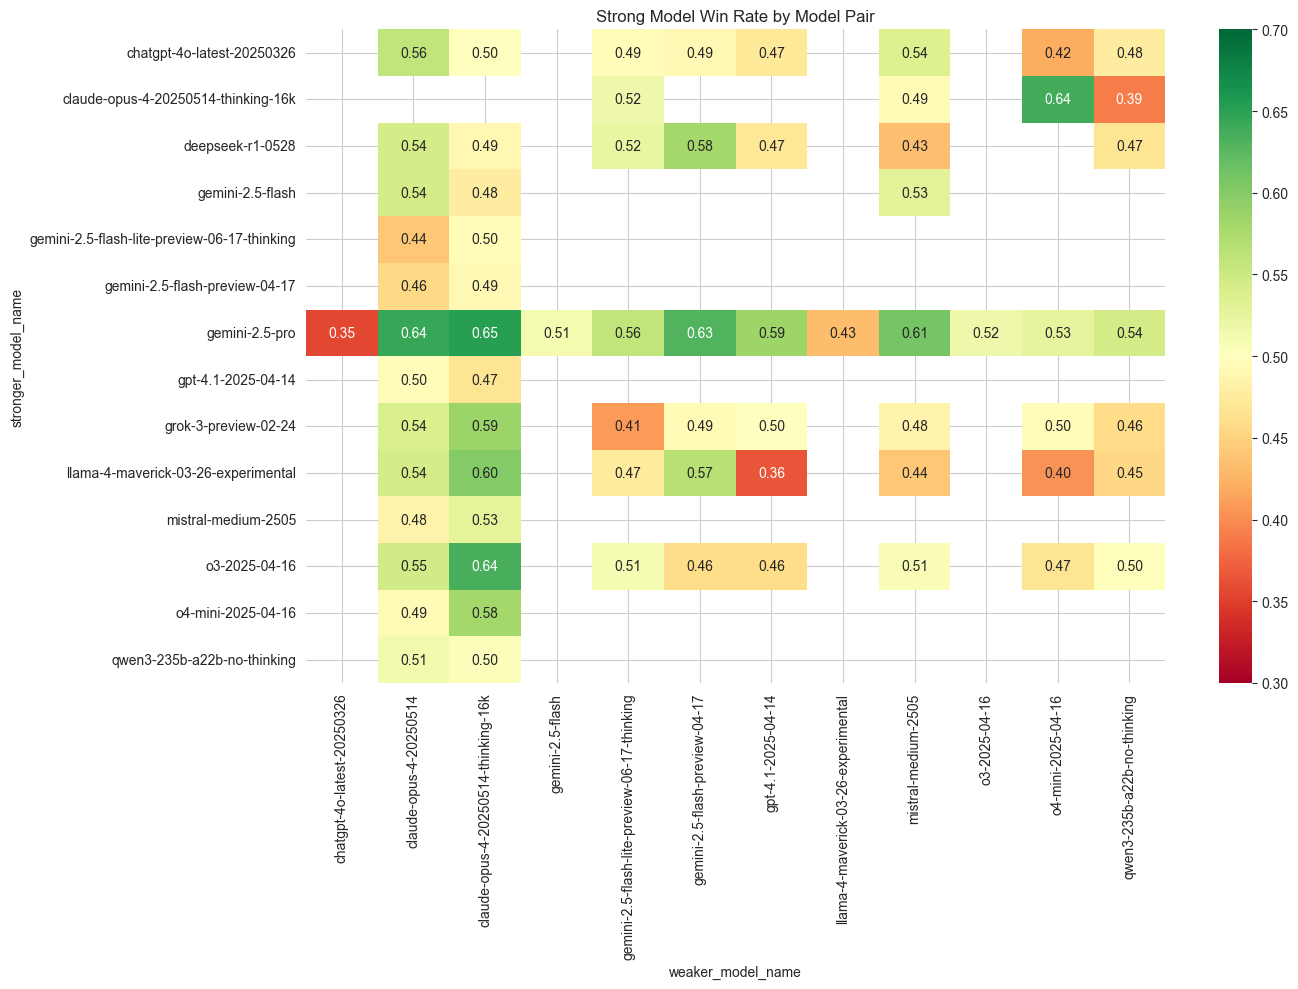

In [19]:
top_models = df['stronger_model_name'].value_counts().head(15).index.tolist()
pivot = pair_stats_filtered[
    pair_stats_filtered['stronger_model_name'].isin(top_models) &
    pair_stats_filtered['weaker_model_name'].isin(top_models)
].pivot_table(index='stronger_model_name', columns='weaker_model_name', values='win_rate')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5, vmin=0.3, vmax=0.7)
plt.title('Strong Model Win Rate by Model Pair')
plt.tight_layout()
plt.savefig('model_pair_heatmap.png', dpi=150)
plt.show()

### 2A-4d: Language Stratification

--- Strong model win rate by language ---
              n  win_rate
language                 
zh         3776  0.629767
ko         1452  0.625344
ja         1445  0.600692
pl         8237  0.598397
fr         1292  0.574303
ru         5321  0.564180
en        41511  0.546698
pt          993  0.534743
de         2599  0.532897
und        6861  0.531264


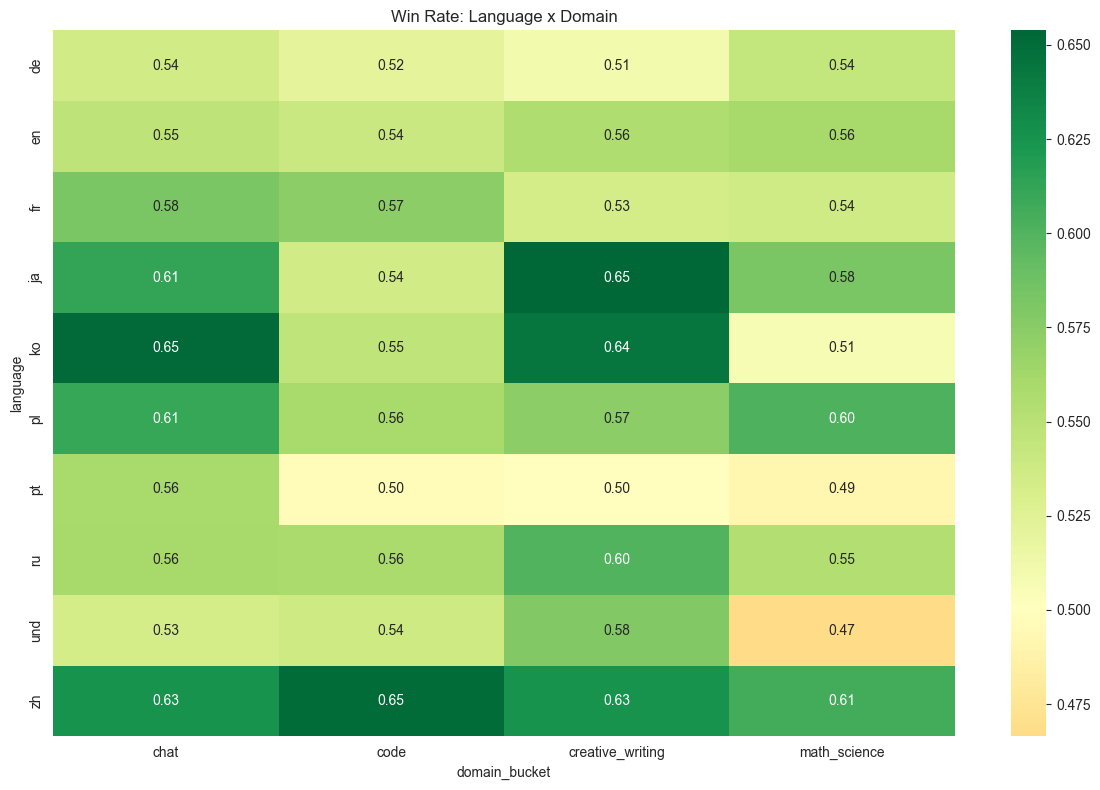

In [20]:
top_langs = df['language'].value_counts().head(10).index
lang_stats = df[df['language'].isin(top_langs)].groupby('language').agg(
    n=('strong_model_won', 'count'),
    win_rate=('strong_model_won', 'mean'),
).sort_values('win_rate', ascending=False)

print("--- Strong model win rate by language ---")
print(lang_stats.to_string())

# Interaction: language x domain
lang_domain = df[df['language'].isin(top_langs)].groupby(
    ['language', 'domain_bucket']
)['strong_model_won'].agg(['mean', 'count']).reset_index()
lang_domain = lang_domain[lang_domain['count'] >= 50]

pivot_ld = lang_domain.pivot_table(index='language', columns='domain_bucket', values='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_ld, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5)
plt.title('Win Rate: Language x Domain')
plt.tight_layout()
plt.savefig('language_domain_interaction.png', dpi=150)
plt.show()

---
## Phase 2A Complete

**Artifacts produced:**
- `arena_enriched_phase2.parquet` — full dataset with Tier 2 + Tier 3 features
- `phase2_artifacts.pkl` — PCA model, train/val/test indices, feature lists

**Plots saved:**
- `tier2_feature_distributions.png`
- `tier2_feature_correlations.png`
- `model_pair_heatmap.png`
- `language_domain_interaction.png`

**Next:** Run `Phase2B_Models.ipynb` for modeling, SHAP analysis, and evaluation.